### **Import libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.ticker import MaxNLocator, FuncFormatter

### **Parameters for Main Experiment**

In [2]:
np.random.seed(42)
n_samples = 1000                   # Both training and testing data
n_features = 10
mus = np.linspace(0, 2, 11)        # Mean shift
theta_star = np.ones(n_features)   # True weights
experiment_count = 50

### **Custom function to generate synthetic data**

In [3]:
def generate_data(n_samples, n_features, mu, theta_star, noise_std=1):
    """
    Generate synthetic training and testing data.
    Training data: N(0, 1)
    Testing data: N(mu, 1)
    """
    X = np.random.normal(mu, 1, (n_samples, n_features))
    Y = X @ theta_star + np.random.normal(0, noise_std, n_samples)

    return X, Y

In [ ]:
# # TEMPORARY

# X_train, Y_train = generate_data(n_samples, n_features, 0, theta_star)
# X_train = X_train + np.random.normal(0, 0.1, X_train.shape)

# X_test, Y_test = generate_data(n_samples, n_features, 2, theta_star)
# # X_test = X_test + np.random.normal(0, 0.1, X_test.shape)

# plt.figure(figsize=(8, 6))
# plt.scatter(X_train, Y_train, color='blue', label='Train Data', alpha=0.7)
# plt.scatter(X_test, Y_test, color='red', label='Test Data', alpha=0.7)
# plt.xlabel('X')
# plt.ylabel('Y')
# # plt.title('Train vs Test Data')
# plt.legend()
# # plt.grid(True)
# plt.show()

### **Generate Train and Test Data**

In [10]:
X_train, Y_train = generate_data(n_samples, n_features, 0, theta_star)
X_train = X_train + np.random.normal(0, 0.1, X_train.shape)

test_data = {mu: [] for mu in mus}

# Loop to generate and store data
for mu in mus:
    for exp in range(experiment_count):
        X_test, Y_test = generate_data(n_samples, n_features, mu, theta_star)
        # X_test = X_test + np.random.normal(0, 0.1, X_test.shape)
        test_data[mu].append((X_test, Y_test))

### **OLS (Closed Form) and Gradient Descent Estimator**

In [5]:
def ols_closed_form(X, y):

    return np.linalg.inv(X.T @ X) @ X.T @ y

def gradient_descent(X, Y, theta_init, gamma, T_values):
    theta = theta_init.copy()
    theta_hats_gd = {T: [] for T in range(1, T_values + 1)}
    gradient_norms = []

    for t in range(1, T_values + 1):
        gradient = (2 / len(Y)) * (X.T @ X @ theta - X.T @ Y)
        gradient_norms.append(np.linalg.norm(gradient))
        theta -= gamma * gradient
        theta_hats_gd[t] = theta.copy()

    return theta_hats_gd, gradient_norms

### **Calculate MSE**

In [6]:
def calculate_metrics(y_true, y_pred):

    return np.mean((y_true - y_pred)**2)

### **OLS Experiment**

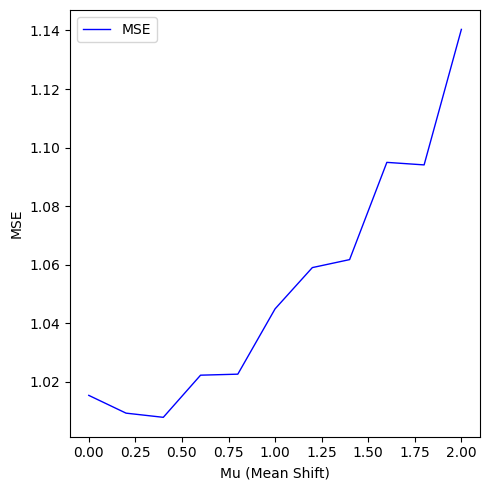

In [11]:
mses_ols = []
theta_hat_ols = ols_closed_form(X_train, Y_train)

for mu in mus:
    mses_mu = []

    test_data_mu = test_data[mu]

    for X_test, Y_test in test_data_mu:
      Y_pred = np.dot(X_test, theta_hat_ols)
      mse = calculate_metrics(Y_test, Y_pred)
      mses_mu.append(mse)

    # Calculate the average MSE for the current mu
    avg_mse = np.mean(mses_mu)
    mses_ols.append(avg_mse)

# Plot the results
fig, ax1 = plt.subplots(figsize=(5, 5))

ax1.plot(mus, mses_ols, color='blue', label='MSE', linewidth=1)
ax1.set_xlabel('Mu (Mean Shift)',fontweight=10)
ax1.set_ylabel('MSE', fontweight=10)
# ax1.set_title('Effect of Mean Shift on MSE in OLS Estimator setup', fontweight=14)
ax1.legend(loc='upper left', bbox_to_anchor=(0, 1))

plt.tight_layout()
# plt.savefig("figureX.png")

### **Gradient Descent Experiment**

In [119]:
gamma = 0.05
T_max = 250  # Maximum stopping time
T_values = np.arange(1, T_max + 1)

theta_init = np.zeros(n_features)
theta_hats_gd, gradient_norm = gradient_descent(X_train, Y_train, theta_init, gamma, T_max)

results = pd.DataFrame(index=mus, columns=T_values)

for mu in mus:
    mses_mu_T = np.zeros((experiment_count, T_max))

    test_data_mu = test_data[mu]

    for exp, (X_test, Y_test) in enumerate(test_data_mu):
        for T in T_values:
          Y_pred = np.dot(X_test, theta_hats_gd[T])
          mse = calculate_metrics(Y_test, Y_pred)
          mses_mu_T[exp, T - 1] = mse

    avg_mses_T = np.mean(mses_mu_T, axis=0)
    results.loc[mu] = avg_mses_T

results = results.astype(float)

Text(0.5, 36.72222222222221, 'Iterations (T)')

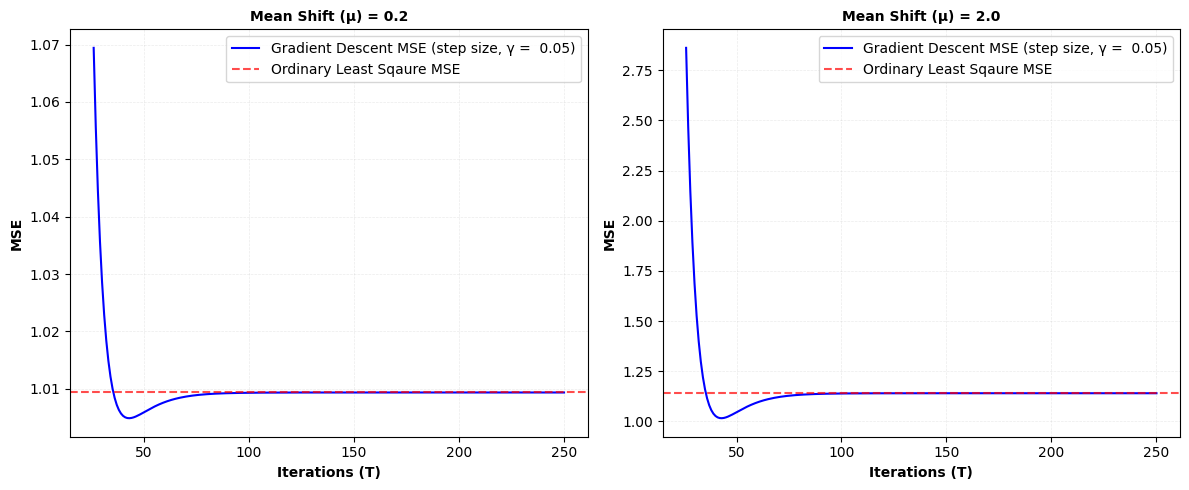

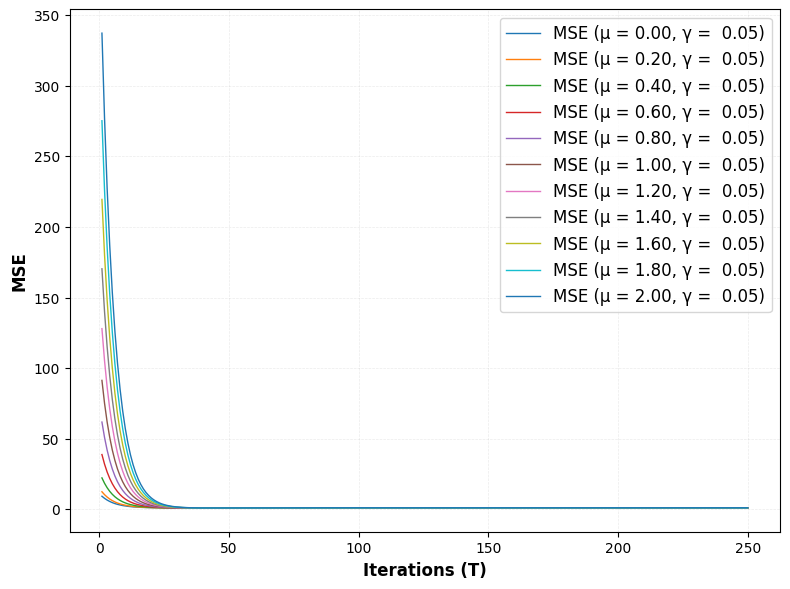

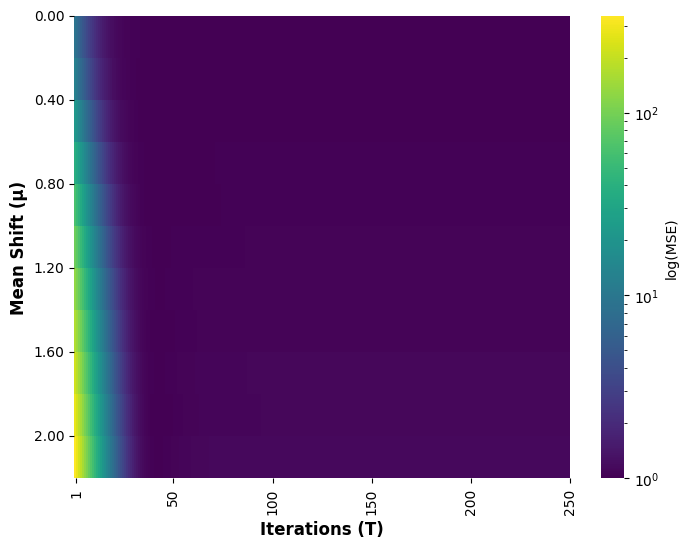

In [121]:
# Plot 1: Plot MSE vs T for a fixed mu
mu_values = [0.2, 2.0]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mu_ols_dict = {mu: mses_ols[i] for i, mu in enumerate(mus)}

for i, mu in enumerate(mu_values):
    axes[i].plot(T_values[25:], results.loc[mu][25:], label=f'Gradient Descent MSE (step size, γ = {gamma: .2f})', color='blue')
    axes[i].axhline(y=mu_ols_dict[mu], color='red', linestyle='--', label=f'Ordinary Least Sqaure MSE', alpha=0.7)
    axes[i].set_title(f'Mean Shift (μ) = {mu}', fontsize=10, fontweight= 'bold')
    axes[i].set_xlabel('Iterations (T)', fontsize=10, fontweight= 'bold')
    axes[i].set_ylabel('MSE', fontsize=10, fontweight= 'bold')
    axes[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)
    axes[i].legend(fontsize=10)

plt.tight_layout()
# plt.savefig("figureB.png")

# Plot 2: Plot MSE vs T for multiple values of mu
fig, ax = plt.subplots(figsize=(8, 6))

for mu in mus:
    ax.plot(T_values, results.loc[mu], label=f'MSE (μ = {mu:.2f}, γ = {gamma: .2f})', linewidth=1)

# ax.set_title('MSE vs Iterations for Different Mean Shifts', fontweight=10)
ax.set_xlabel('Iterations (T)', fontsize=12, fontweight='bold')
ax.set_ylabel('MSE', fontsize=12, fontweight = 'bold')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.25)
ax.legend(fontsize=12)
plt.tight_layout()
# plt.savefig("figureC.png")

# Plot 3: Heatmap of MSE with axes mu (rows) and T (columns)
heatmap_data = results.values
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, cmap="viridis", cbar_kws={'label': 'log(MSE)'}, fmt=".3f", xticklabels=T_values, yticklabels=mus,
           norm=LogNorm(vmin=heatmap_data.min(), vmax=heatmap_data.max()))

xticks_to_show = [1, 50, 100, 150, 200, 250] #, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]
yticks_to_show = [0, 2, 4, 6, 8, 10]

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True, prune='both', nbins=6))
plt.xticks(ticks=xticks_to_show, labels=[T_values[i-1] for i in xticks_to_show], rotation=90)

# plt.gca().yaxis.set_major_locator(MaxNLocator(prune='both', nbins=6))
plt.yticks(ticks=yticks_to_show, labels=[f'{mus[i]:.2f}' for i in yticks_to_show])

# plt.yticks(ticks=np.arange(len(mus)), labels=[f'{mu:.2f}' for mu in mus])

# plt.title(f'Step size, γ = {gamma: .2f}', fontsize=10, fontweight = 'bold')
plt.ylabel('Mean Shift (μ)', fontsize=12, fontweight = 'bold')
plt.xlabel('Iterations (T)', fontsize=12, fontweight = 'bold')
# plt.savefig("figureD.png")

### **Plotting Gradient Norms**

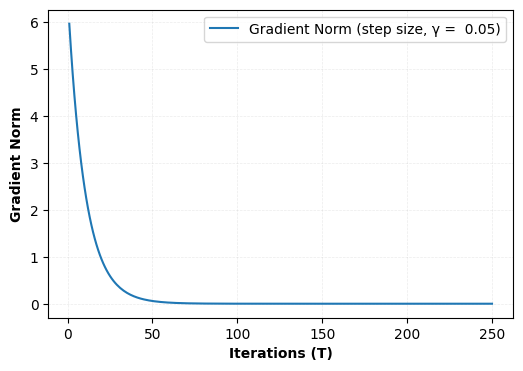

In [122]:
# print(gradient_norm[1400:1500])

plt.figure(figsize=(6, 4))
plt.plot(range(1, T_max + 1), gradient_norm[:], label=f'Gradient Norm (step size, γ = {gamma: .2f})')
plt.xlabel("Iterations (T)", fontsize=10, fontweight='bold')
plt.ylabel("Gradient Norm", fontsize=10, fontweight='bold')
# plt.title("Gradient Norms Over Iterations")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.25)
plt.legend(fontsize=10)
plt.show()

### **Plotting Theta Norms**

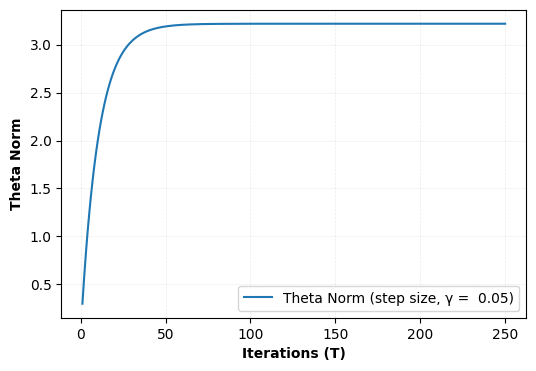

In [123]:
theta_norms = [np.linalg.norm(theta_hats_gd[T]) for T in T_values]
# print(theta_norms[1400:1500])

# theta_hats_list = [theta_hats_gd[T] for T in T_values]
# print(theta_hats_list[650:800])

plt.figure(figsize=(6, 4))
plt.plot(T_values, theta_norms, label=f'Theta Norm (step size, γ = {gamma: .2f})')
plt.xlabel('Iterations (T)', fontsize=10, fontweight='bold')
plt.ylabel('Theta Norm', fontsize=10, fontweight='bold')
# plt.title('Theta Norm Over Iterations')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.25)
plt.legend(fontsize=10)
plt.show()

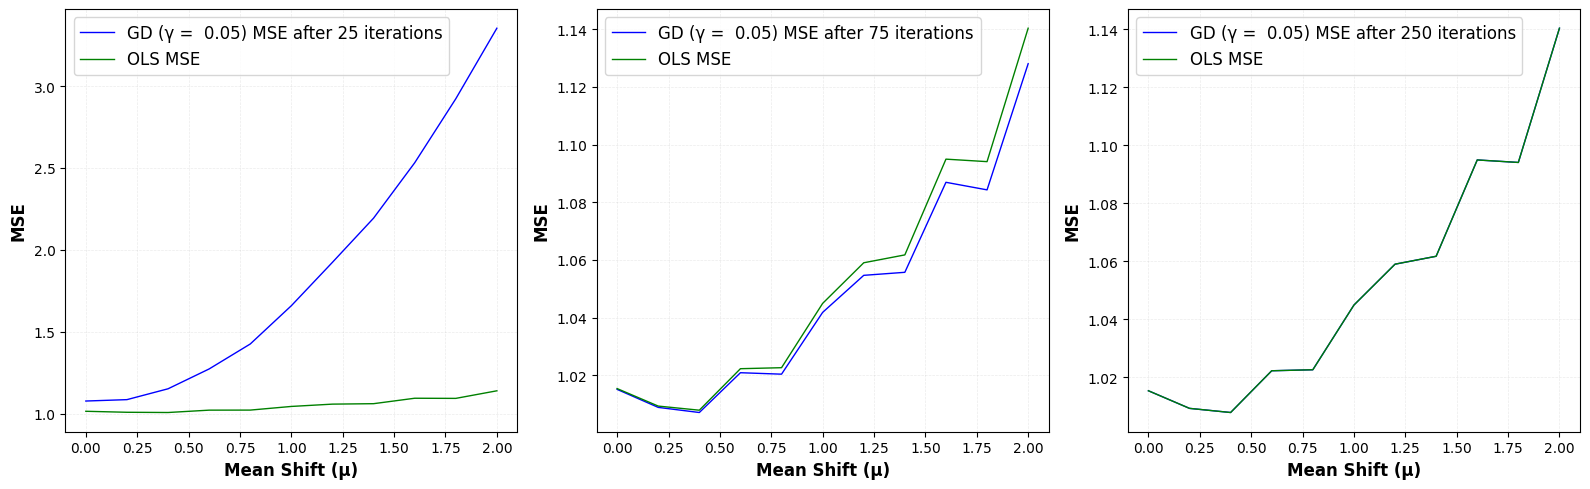

In [124]:
checkpoints = [25, 75, T_values[len(T_values)-1]]
fig, axes = plt.subplots(1, len(checkpoints), figsize=(16, 5))

mse_values_checkpoints = []
for checkpoint in checkpoints:
    mse_values_checkpoints.append(results[checkpoint])

for i in range(len(checkpoints)):
    axes[i].plot(mus, mse_values_checkpoints[i], color='blue', label=f'GD (γ = {gamma: .2f}) MSE after {checkpoints[i]} iterations', linewidth=1)
    axes[i].plot(mus, mses_ols, color='green', label='OLS MSE', linewidth=1)
    axes[i].set_xlabel('Mean Shift (μ)', fontsize=12, fontweight = 'bold')
    axes[i].set_ylabel('MSE', fontsize=12, fontweight = 'bold')
    axes[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)
    axes[i].legend(loc='best', fontsize=12)

# fig.suptitle('Effect of Mean Shift on MSE (OLS vs GD)', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

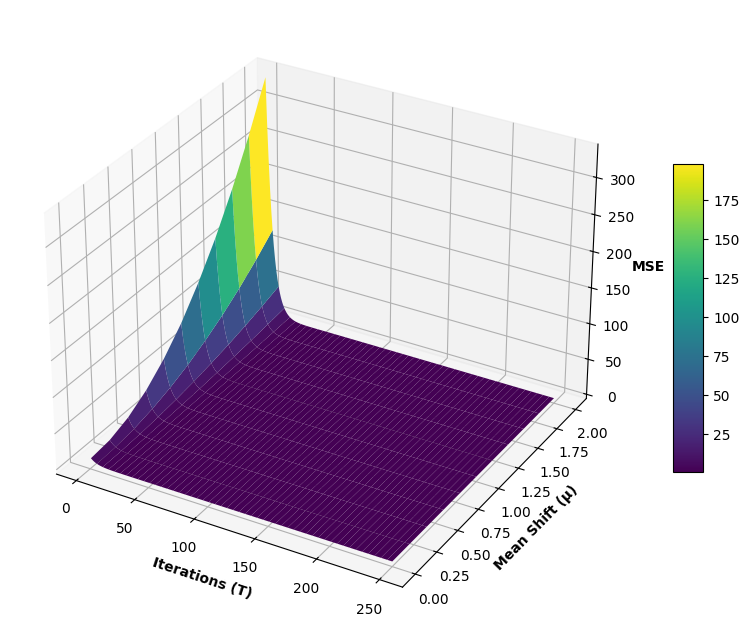

In [125]:
mu_mesh, T_mesh = np.meshgrid(mus, T_values)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T_mesh, mu_mesh, results.T, cmap='viridis', edgecolor='none')
ax.set_ylabel('Mean Shift (μ)', fontsize=10, fontweight='bold')
ax.set_xlabel('Iterations (T)', fontsize=10, fontweight='bold')
ax.set_zlabel('MSE', fontsize=10, fontweight='bold')
# ax.set_title('MSE Variation with Mu and T_values in Gradient Descent')
# ax.set_title(f'Step size, γ = {gamma: .2f}', fontsize=10, fontweight = 'bold')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

plt.show()

### **Importance weighting: Density Ratio Estimation**

In [126]:
from sklearn.neighbors import KernelDensity
# from sklearn.model_selection import GridSearchCV

def estimate_weight(X_train, X_test, bandwidth=0.5):

    # params={'bandwidth': np.logspace(-1, 1, 10)}
    # grid = GridSearchCV(KernelDensity(kernel='gaussian'), params, cv=3)
    # grid.fit(X_train)
    # kde_source = grid.best_estimator_

    # grid.fit(X_test)
    # kde_target = grid.best_estimator_

    kde_source = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(X_train)
    kde_target = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(X_test)

    log_density_source = kde_source.score_samples(X_train)
    log_density_target = kde_target.score_samples(X_train)
    weights = np.exp(log_density_target - log_density_source)  # Density ratio

    return weights

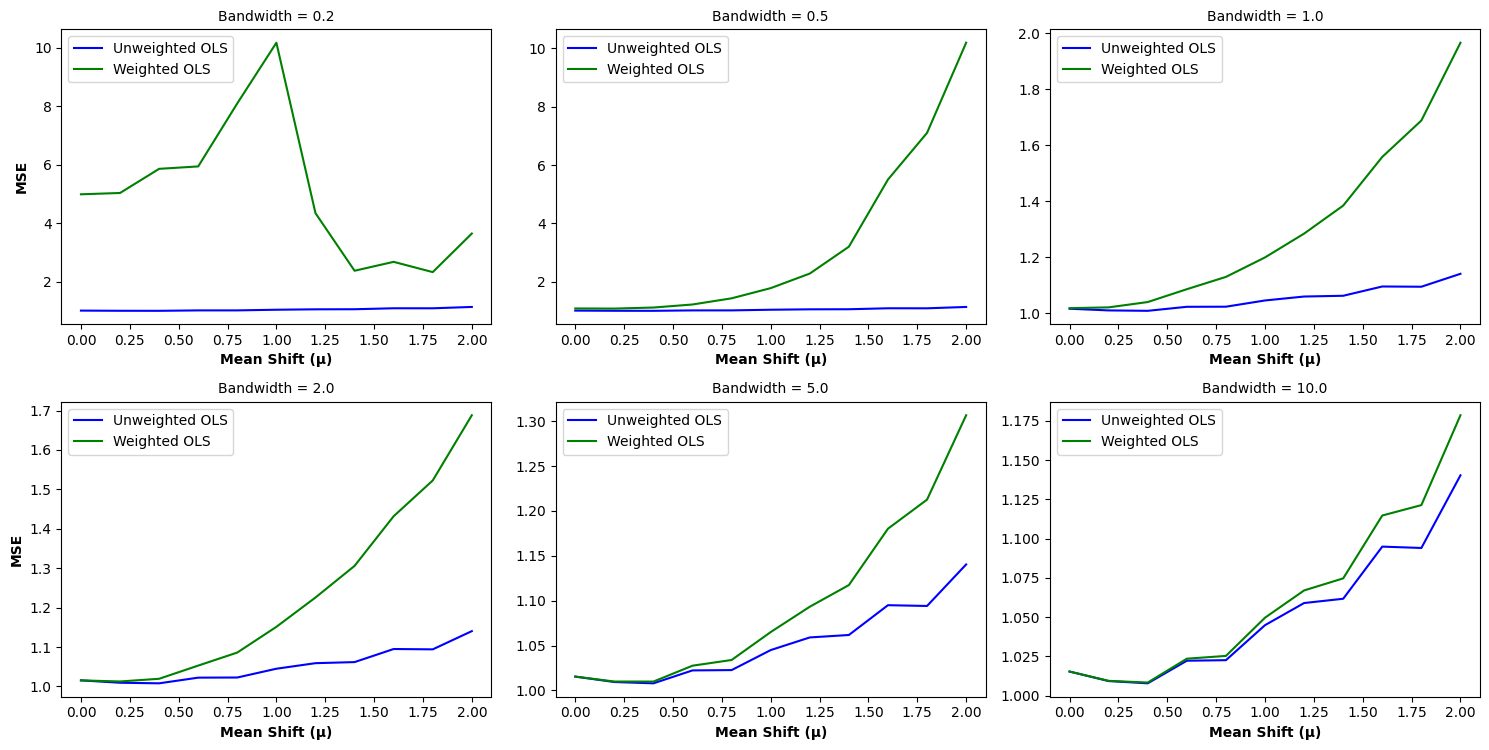

In [131]:
def ols_closed_form_weighted(X, y, weights):

    W = np.diag(weights)
    theta_hat_ols_dre = np.linalg.inv(X.T @ W @ X) @ X.T @ W @ y
    return theta_hat_ols_dre

# bandwidths = [0.2, 0.50, 1.0, 2.0]
# fig, axes = plt.subplots(1, len(bandwidths), figsize=(20, 4), sharey=False)

# for idx, bandwidth in enumerate(bandwidths):
#   mses_ols_weighted = []

#   for mu in mus:
#     mse_mu_weighted = []

#     for X_test, Y_test in test_data[mu]:
#       weights = estimate_weight(X_train, X_test, bandwidth)
#       theta_hat_ols_weighted = ols_closed_form_weighted(X_train, Y_train, weights)
#       # Y_pred_weighted = X_test @ theta_hat_ols_weighted
#       Y_pred_weighted = np.dot(X_test, theta_hat_ols_weighted)
#       mse_mu_weighted.append(calculate_metrics(Y_test, Y_pred_weighted))

#     mses_ols_weighted.append(np.mean(mse_mu_weighted))

#   # Plot results for the current bandwidth
#   ax = axes[idx]
#   ax.plot(mus, mses_ols, label='Unweighted OLS', color='blue')
#   ax.plot(mus, mses_ols_weighted, label='Weighted OLS', color='green')
#   ax.set_title(f'Bandwidth = {bandwidth}', fontsize=14)
#   ax.set_xlabel('Mean Shift (mu)', fontsize=12)
#   if idx == 0:
#     ax.set_ylabel('MSE', fontsize=12)
#   # ax.grid()
#   ax.legend()

# # fig.suptitle('Effect of Importance Weighting (Density Ratio Estimation) with different bandwidth on MSE in Mean Shift setup', fontsize=16)
# plt.tight_layout(rect=[0, 0, 1, 0.95])
# # plt.savefig('figure_mean_shift_vs_mse_multiple_bandwidths.png')
# plt.show()

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

bandwidths = [0.2, 0.50, 1.0, 2.0, 5.0, 10.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for idx, bandwidth in enumerate(bandwidths):
    mses_ols_weighted = []

    for mu in mus:
        mse_mu_weighted = []

        for X_test, Y_test in test_data[mu]:
            weights = estimate_weight(X_train, X_test, bandwidth)
            theta_hat_ols_weighted = ols_closed_form_weighted(X_train, Y_train, weights)
            # Y_pred_weighted = X_test @ theta_hat_ols_weighted
            Y_pred_weighted = np.dot(X_test, theta_hat_ols_weighted)
            mse_mu_weighted.append(calculate_metrics(Y_test, Y_pred_weighted))

        mses_ols_weighted.append(np.mean(mse_mu_weighted))

    # Select subplot from the 2x2 grid
    ax = axes[idx]
    ax.plot(mus, mses_ols, label='Unweighted OLS', color='blue')
    ax.plot(mus, mses_ols_weighted, label='Weighted OLS', color='green')
    ax.set_title(f'Bandwidth = {bandwidth}', fontsize=10)
    ax.set_xlabel('Mean Shift (μ)', fontsize=10, fontweight='bold')
    if idx % 3 == 0:  # Only first column should have y-label
        ax.set_ylabel('MSE', fontsize=10, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)


# fig.suptitle('Effect of Importance Weighting (Density Ratio Estimation) with Different Bandwidths on MSE in Mean Shift Setup', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

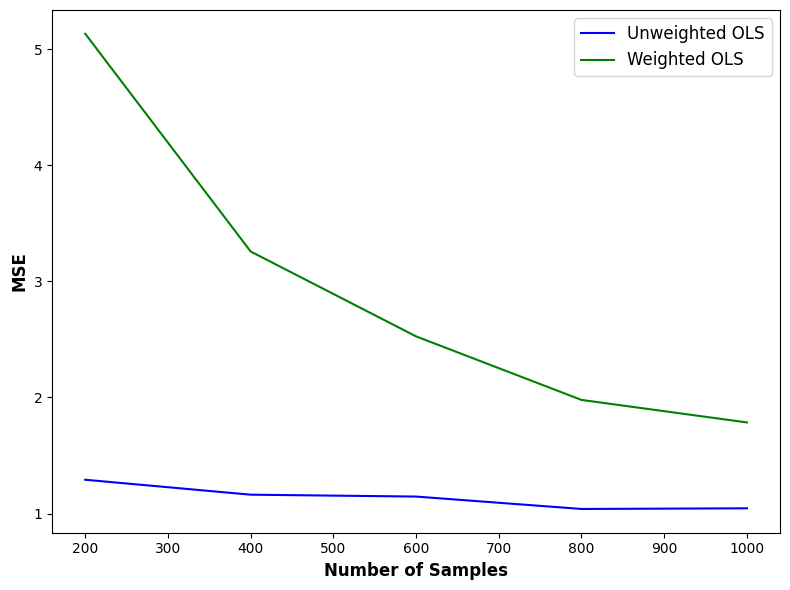

In [146]:
# Define the parameters
sample_sizes = [200, 400, 600, 800, 1000]
fixed_mu = 1.0  # Fixed mean shift

mse_ols_unweighted_samples = []
mse_ols_weighted_samples = []

for n_samples in sample_sizes:
    mse_unweighted = []
    mse_weighted = []

    X_train_subset = X_train[:n_samples]
    Y_train_subset = Y_train[:n_samples]

    theta_hat_ols_unweighted = np.linalg.inv(X_train_subset.T @ X_train_subset) @ X_train_subset.T @ Y_train_subset

    for X_test, Y_test in test_data[fixed_mu]: # Iterate over all experiments for the fixed_mu
        X_test_subset = X_test[:n_samples]
        Y_test_subset = Y_test[:n_samples]

        # Unweighted OLS
        # Y_pred_unweighted = X_test_subset @ theta_hat_ols_unweighted
        Y_pred_unweighted = np.dot(X_test_subset, theta_hat_ols_unweighted)
        mse_unweighted.append(calculate_metrics(Y_test_subset, Y_pred_unweighted))

        # Weighted OLS
        weights = estimate_weight(X_train_subset, X_test_subset, bandwidth=0.5)  # Fix bandwidth
        theta_hat_ols_weighted = ols_closed_form_weighted(X_train_subset, Y_train_subset, weights)
        # Y_pred_weighted = X_test_subset @ theta_hat_ols_weighted
        Y_pred_weighted = np.dot(X_test_subset, theta_hat_ols_weighted)
        mse_weighted.append(calculate_metrics(Y_test_subset, Y_pred_weighted))

    # Compute the average MSE across all experiments for this sample size
    mse_ols_unweighted_samples.append(np.mean(mse_unweighted))
    mse_ols_weighted_samples.append(np.mean(mse_weighted))

plt.figure(figsize=(8, 6))
plt.plot(sample_sizes, mse_ols_unweighted_samples, label='Unweighted OLS', color='blue')
plt.plot(sample_sizes, mse_ols_weighted_samples, label='Weighted OLS', color='green')
plt.xlabel('Number of Samples', fontsize=12, fontweight='bold')
plt.ylabel('MSE', fontsize=12, fontweight='bold')
# plt.title(f'Effect of Sample Size on MSE (mu={fixed_mu}, bandwidth=0.5)', fontsize=14)
plt.legend(fontsize=12)
# plt.grid()
plt.tight_layout()
# plt.savefig('figure_test_samples_vs_mse.png')
plt.show()

In [147]:
def gradient_descent_weighted(X, Y, theta_init, gamma, T_values, weights):

    theta = theta_init.copy()
    theta_hats_gd_weighted = {T: None for T in range(1, T_values + 1)}
    W = np.diag(weights)

    for t in range(1, T_values + 1):
        gradient = (2 / len(Y)) * (X.T @ W @ X @ theta - X.T @ W @ Y)
        theta -= gamma * gradient
        theta_hats_gd_weighted[t] = theta.copy()

    return theta_hats_gd_weighted

In [148]:
gamma1 = 0.01
gamma2 = 0.1
T_max = 5000
sample_sizes = [200, 400, 600, 800, 1000]
fixed_mu = 1.0  # Fixed Mean Shift

# Gradient Descent Training (Iterative MSE Calculation)
theta_init = np.zeros(n_features)
theta_hat_gd_unweighted, _ = gradient_descent(X_train, Y_train, theta_init, gamma1, T_max)

mse_gd_unweighted_iterations = np.zeros(T_max)
mse_gd_weighted_iterations = np.zeros(T_max)

for X_test, Y_test in test_data[fixed_mu]:
  weights = estimate_weight(X_train, X_test, bandwidth=0.5)
  theta_hat_gd_weighted = gradient_descent_weighted(X_train, Y_train, theta_init, gamma2, T_max, weights)

  for T in range(1, T_max + 1):
    # Unweighted GD
    Y_pred_unweighted = np.dot(X_test, theta_hat_gd_unweighted[T])
    mse_gd_unweighted_iterations[T-1] += calculate_metrics(Y_test, Y_pred_unweighted)

    # Weighted GD
    Y_pred_weighted = np.dot(X_test, theta_hat_gd_weighted[T])
    mse_gd_weighted_iterations[T-1] += calculate_metrics(Y_test, Y_pred_weighted)

mse_gd_unweighted_iterations /= len(test_data[fixed_mu])
mse_gd_weighted_iterations /= len(test_data[fixed_mu])


# Gradient Descent Training (Sample Size MSE Calculation)
mse_gd_unweighted_samples = []
mse_gd_weighted_samples = []

for n_samples in sample_sizes:
    mse_unweighted = []
    mse_weighted = []

    X_train_subset = X_train[:n_samples]
    Y_train_subset = Y_train[:n_samples]
    theta_hat_gd_unweighted, _ = gradient_descent(X_train_subset, Y_train_subset, theta_init, gamma1, T_max)

    for X_test, Y_test in test_data[fixed_mu]:
        X_test_subset = X_test[:n_samples]
        Y_test_subset = Y_test[:n_samples]

        # Unweighted GD
        # Y_pred_unweighted = X_test_subset @ theta_hat_gd_unweighted[T_max]
        Y_pred_unweighted = np.dot(X_test_subset, theta_hat_gd_unweighted[T_max])
        mse_unweighted.append(calculate_metrics(Y_test_subset, Y_pred_unweighted))

        # Weighted GD
        weights = estimate_weight(X_train_subset, X_test, bandwidth=0.5)
        theta_hat_gd_weighted = gradient_descent_weighted(X_train_subset, Y_train_subset, theta_init, gamma2, T_max, weights)
        # Y_pred_weighted = X_test_subset @ theta_hat_gd_weighted[T_max]
        Y_pred_weighted = np.dot(X_test_subset, theta_hat_gd_weighted[T_max])
        mse_weighted.append(calculate_metrics(Y_test_subset, Y_pred_weighted))

    mse_gd_unweighted_samples.append(np.mean(mse_unweighted))
    mse_gd_weighted_samples.append(np.mean(mse_weighted))

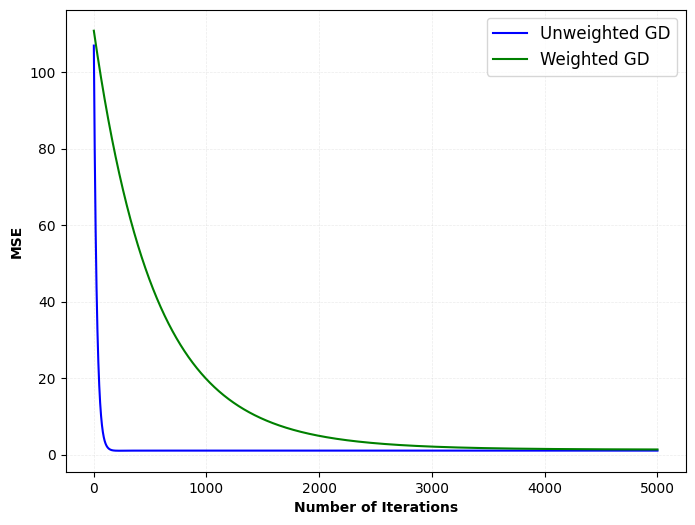

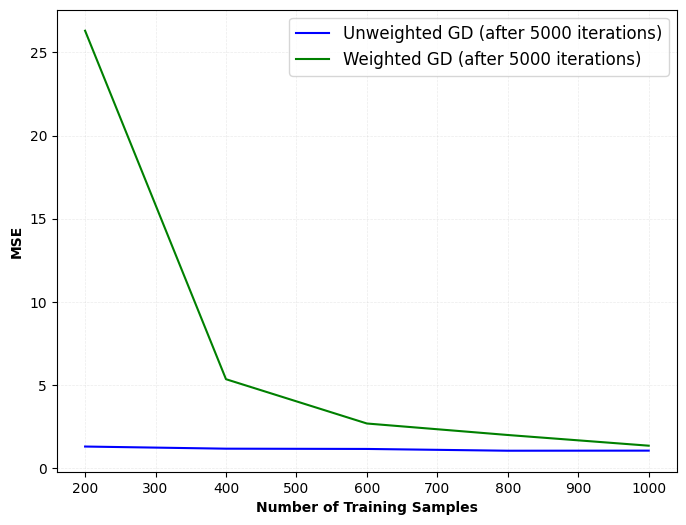

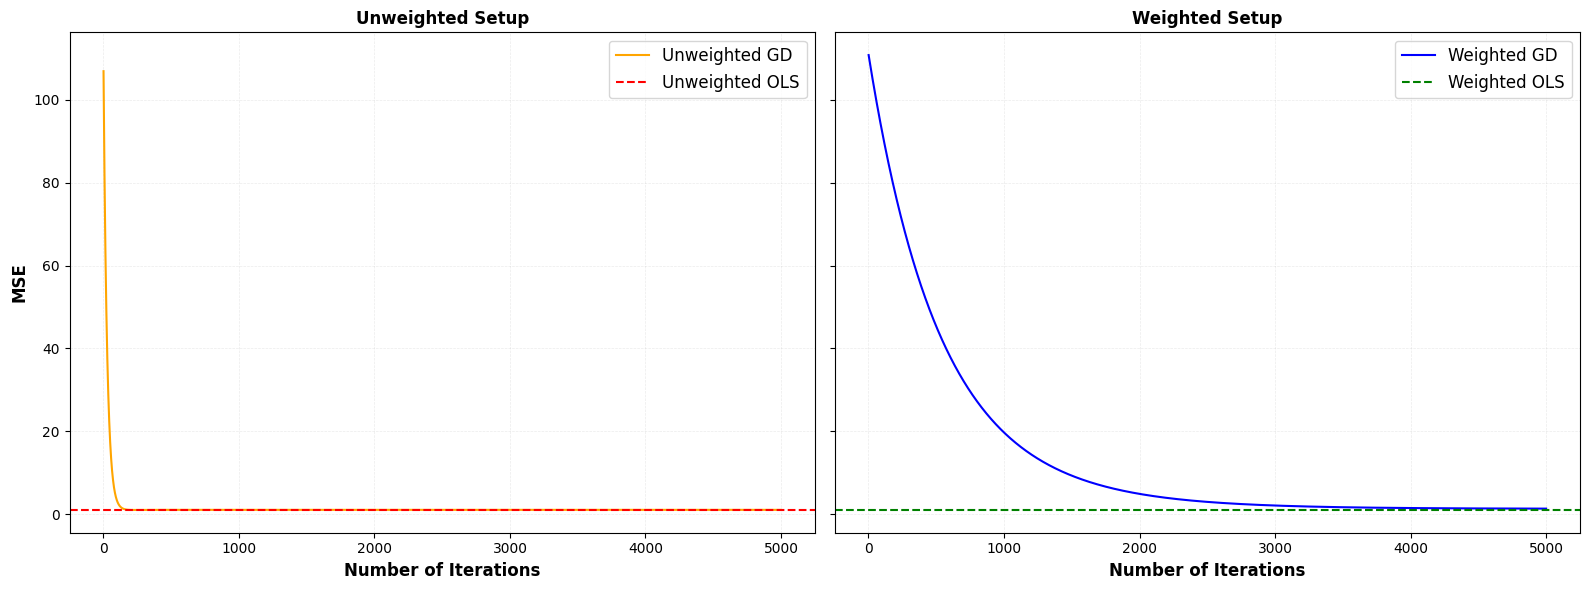

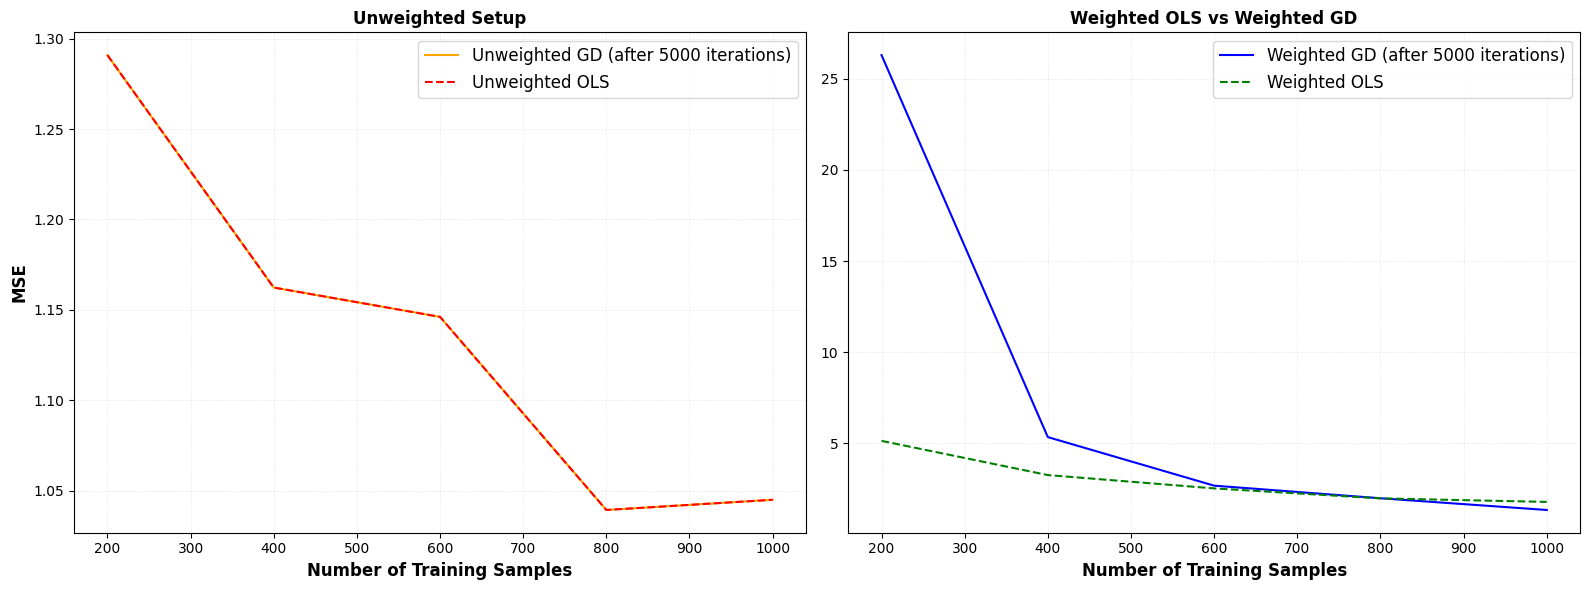

In [156]:
# Plot 1: Iterations vs MSE for GD (Weighted vs Unweighted)
plt.figure(figsize=(8, 6))
plt.plot(range(1, T_max + 1), mse_gd_unweighted_iterations, label='Unweighted GD', color='blue')
plt.plot(range(1, T_max + 1), mse_gd_weighted_iterations, label='Weighted GD', color='green')
plt.xlabel('Number of Iterations', fontsize=10, fontweight='bold')
plt.ylabel('MSE', fontsize=10, fontweight='bold')
# plt.title(f'Iterations vs MSE for GD with Fixed Mean Shift ={fixed_mu}: Weighted vs Unweighted', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.25)
# plt.savefig('figure_gd_iterations_vs_mse.png')
plt.show()

# Plot 2: Sample Size vs MSE for Iterations = 1500 (Weighted vs Unweighted GD)
plt.figure(figsize=(8, 6))
plt.plot(sample_sizes, mse_gd_unweighted_samples, label=f'Unweighted GD (after {T_max} iterations)', color='blue')
plt.plot(sample_sizes, mse_gd_weighted_samples, label=f'Weighted GD (after {T_max} iterations)', color='green')
plt.xlabel('Number of Training Samples', fontsize=10, fontweight='bold')
plt.ylabel('MSE', fontsize=10, fontweight='bold')
# plt.title(f'Sample Size vs MSE for Iterations = {T_max} and Fixed Mean Shift ={fixed_mu}: Weighted vs Unweighted GD', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.25)
# plt.savefig('figure_gd_samples_vs_mse.png')
plt.show()

# Plot 3: Unweighted vs Weighted GD vs OLS (Iterations)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

T_values = np.arange(1, T_max + 1)
iter_start = 80
iter_end = 250
# Unweighted OLS vs Unweighted GD
axes[0].plot(range(1, T_max + 1), mse_gd_unweighted_iterations, label='Unweighted GD', color='orange')
# axes[0].plot(T_values[iter_start:iter_end], mse_gd_unweighted_iterations[iter_start:iter_end], label='Unweighted GD', color='orange')
axes[0].axhline(y=mu_ols_dict[fixed_mu], color='red', linestyle='--', label='Unweighted OLS')
axes[0].set_title('Unweighted Setup', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Iterations', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MSE', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)

# Weighted OLS vs Weighted GD
axes[1].plot(range(1, T_max + 1), mse_gd_weighted_iterations, label='Weighted GD', color='blue')

mu_index = mus.tolist().index(fixed_mu)
bandwidth_index = bandwidths.index(0.5)
weighted_ols_mse = mses_ols_weighted[mu_index]
axes[1].axhline(y=weighted_ols_mse, color='green', linestyle='--', label='Weighted OLS')
axes[1].set_title('Weighted Setup', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Iterations', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)

# plt.suptitle(f'Comparison of OLS and GD across Iterations for Fixed Mean Shift ={fixed_mu} in both Weighted and Unweighted setup', fontweight="bold")
plt.tight_layout()
# plt.savefig('figure_ols_vs_gd_iterations.png')
plt.show()

# Plot 4: Unweighted vs Weighted GD vs OLS (Sample Sizes)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Unweighted OLS vs Unweighted GD
axes[0].plot(sample_sizes, mse_gd_unweighted_samples, label=f'Unweighted GD (after {T_max} iterations)', color='orange')
axes[0].plot(sample_sizes, mse_ols_unweighted_samples, label='Unweighted OLS', color='red', linestyle='--')
axes[0].set_title('Unweighted Setup', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Training Samples', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MSE', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)

# Weighted OLS vs Weighted GD
axes[1].plot(sample_sizes, mse_gd_weighted_samples, label=f'Weighted GD (after {T_max} iterations)', color='blue')
axes[1].plot(sample_sizes, mse_ols_weighted_samples, label='Weighted OLS', color='green', linestyle='--')
axes[1].set_title('Weighted OLS vs Weighted GD', fontsize=12, fontweight="bold")
axes[1].set_xlabel('Number of Training Samples', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)

# plt.suptitle(f'Comparison of OLS and GD across Sample Sizes for Iterations = {T_max} and Fixed Mean Shift ={fixed_mu} in both Weighted and Unweighted', fontweight="bold")
plt.tight_layout()
# plt.savefig('figure_ols_vs_gd_samples.png')
plt.show()

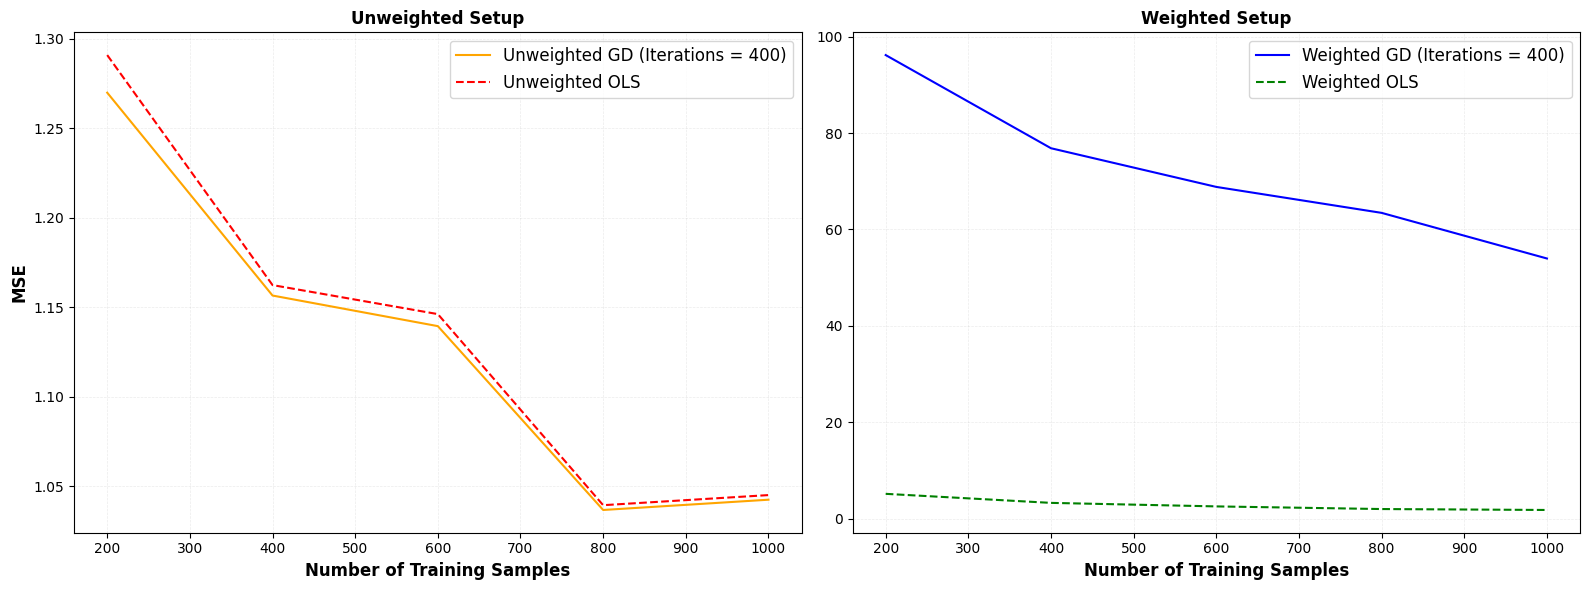

In [159]:
T_max_new = 400
theta_init = np.zeros(n_features)

mse_gd_unweighted_samples_new = []
mse_gd_weighted_samples_new = []

for n_samples in sample_sizes:
    mse_unweighted = []
    mse_weighted = []

    X_train_subset = X_train[:n_samples]
    Y_train_subset = Y_train[:n_samples]

    # Run Gradient Descent with reduced iterations
    theta_hat_gd_unweighted_new, _ = gradient_descent(X_train_subset, Y_train_subset, theta_init, gamma1, T_max_new)

    for X_test, Y_test in test_data[fixed_mu]:
        X_test_subset = X_test[:n_samples]
        Y_test_subset = Y_test[:n_samples]

        # Unweighted GD with reduced iterations
        Y_pred_unweighted_new = np.dot(X_test_subset, theta_hat_gd_unweighted_new[T_max_new])
        mse_unweighted.append(calculate_metrics(Y_test_subset, Y_pred_unweighted_new))

        # Weighted GD with reduced iterations
        weights = estimate_weight(X_train_subset, X_test_subset, bandwidth=0.5)
        theta_hat_gd_weighted_new = gradient_descent_weighted(X_train_subset, Y_train_subset, theta_init, gamma2, T_max_new, weights)
        Y_pred_weighted_new = np.dot(X_test_subset, theta_hat_gd_weighted_new[T_max_new])
        mse_weighted.append(calculate_metrics(Y_test_subset, Y_pred_weighted_new))

    mse_gd_unweighted_samples_new.append(np.mean(mse_unweighted))
    mse_gd_weighted_samples_new.append(np.mean(mse_weighted))


# Create the plot with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Subplot 1: Unweighted OLS vs Unweighted GD
axes[0].plot(sample_sizes, mse_gd_unweighted_samples_new, label=f'Unweighted GD (Iterations = {T_max_new})', color='orange')
axes[0].plot(sample_sizes, mse_ols_unweighted_samples, label='Unweighted OLS', color='red', linestyle='--')
axes[0].set_title('Unweighted Setup', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Training Samples', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MSE', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)

# Subplot 2: Weighted OLS vs Weighted GD
axes[1].plot(sample_sizes, mse_gd_weighted_samples_new, label=f'Weighted GD (Iterations = {T_max_new})', color='blue')
axes[1].plot(sample_sizes, mse_ols_weighted_samples, label='Weighted OLS', color='green', linestyle='--')
axes[1].set_title('Weighted Setup', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Training Samples', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)

# plt.suptitle(f'Comparison of OLS and GD across Sample Sizes for Iterations = {T_max_new} and Fixed Mean Shift ={fixed_mu} in both Weighted and Unweighted setup', fontweight="bold")
plt.tight_layout()
plt.show()

### **Self-attention Mechanism**

In [160]:
# Masking function and its derivative
def masking(q, weight):
    """Masking function m(w)"""
    if q == -1:
        return np.tanh(weight)  # Bounded masking
    else:
        return weight**q  # Unbounded masking

def masking_derivative(q, weight):
    """Derivative of masking function m'(w)"""
    if q == -1:
        return 1 - np.tanh(weight)**2  # Derivative of tanh(w)
    elif q == 0:
        return np.ones_like(weight)  # Constant 1
    else:
        return q * weight**(q - 1)  # Power rule

def gradient_descent_sa(X, Y, theta_init, weight_init, gamma_theta, gamma_weight, T_values, q):
    n_samples, n_features = X.shape
    theta = theta_init.copy()
    weight = weight_init.copy()

    gradient_theta_list = []
    gradient_weight_list = []

    theta_hats_sa = {T: [] for T in range(1, T_values + 1)}
    weight_hats_sa = {T: [] for T in range(1, T_values + 1)}

    for t in range(1, T_values + 1):
        # Compute masking function and its derivative
        mask = masking(q, weight)
        mask_derivative = masking_derivative(q, weight)

        # Compute gradients
        residuals = X @ theta - Y  # (n_samples,)
        loss_vector = residuals**2  # Element-wise squared loss

        gradient_theta = (2 / n_samples) * X.T @ (mask * residuals)
        gradient_weight = (1 / n_samples) * mask_derivative * loss_vector

        gradient_theta_list.append(gradient_theta)
        gradient_weight_list.append(gradient_weight)

        # Gradient updates
        theta -= gamma_theta * gradient_theta  # Gradient descent step for theta
        weight += gamma_weight * gradient_weight  # Gradient ascent step for weights

        # Store updates
        theta_hats_sa[t] = theta.copy()
        weight_hats_sa[t] = weight.copy()

    # print(gradient_theta_list[:10])

    return theta_hats_sa, weight_hats_sa

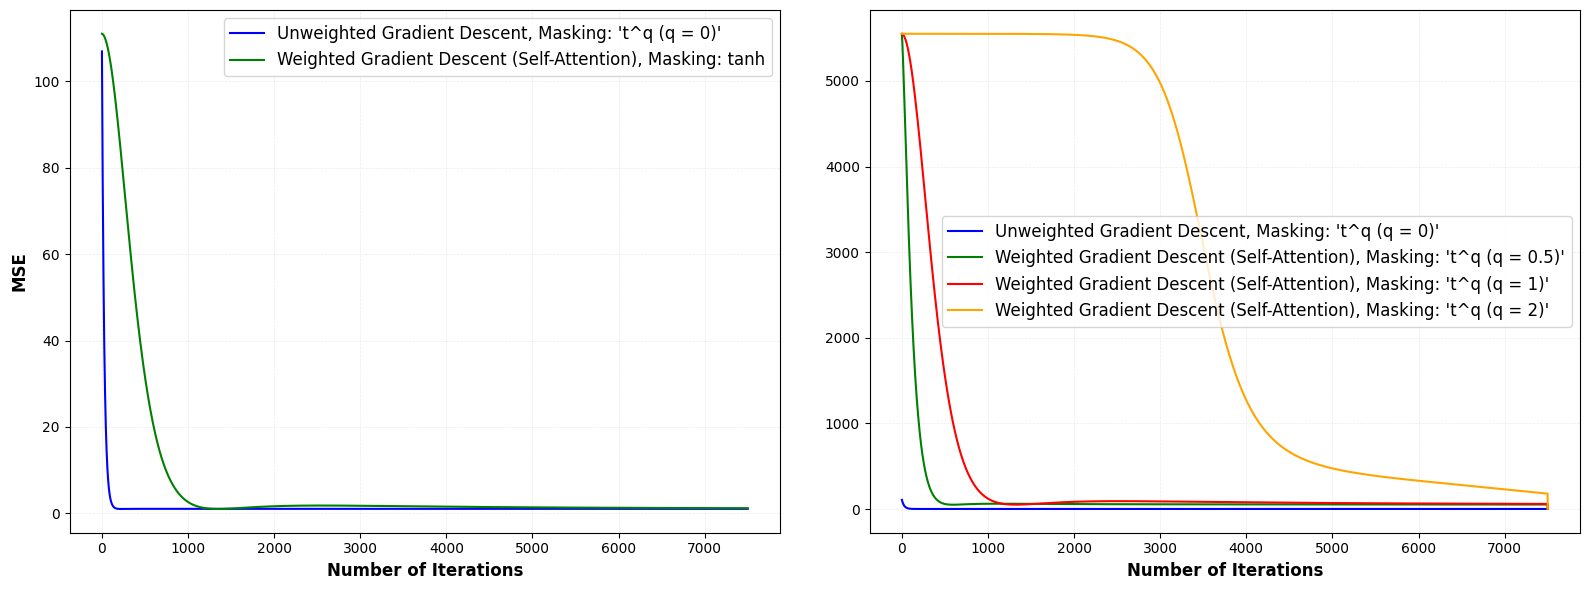

In [161]:
gamma_theta = 0.01
gamma_weight = 0.01
T_max = 7500
# sample_sizes = [200, 400, 600, 800, 1000]
fixed_mu = 1.0


# Parameter initialization
theta_init = np.zeros(n_features)
weight_init = np.full(n_samples, 1e-3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Gradient Descent Training (Iterative MSE Calculation)
theta_hat_sa_unweighted, weight_hat_sa_unweighted = gradient_descent_sa(X_train, Y_train, theta_init, weight_init, gamma_theta, gamma_weight, T_max, 0)

mse_gd_unweighted_iterations = np.zeros(T_max)
mse_gd_sa_iterations = np.zeros(T_max)

for X_test, Y_test in test_data[fixed_mu]:
  # weights = weight_init.copy()
  theta_hat_sa_weighted, weight_hat_sa_weighted = gradient_descent_sa(X_train, Y_train, theta_init, weight_init, gamma_theta, gamma_weight, T_max, -1)

  for T in range(1, T_max + 1):
    # Unweighted GD
    Y_pred_unweighted = np.dot(X_test, theta_hat_sa_unweighted[T])
    mse_gd_unweighted_iterations[T-1] += calculate_metrics(Y_test, Y_pred_unweighted)

    # Weighted GD
    Y_pred_weighted = np.dot(X_test, theta_hat_sa_weighted[T])
    mse_gd_sa_iterations[T-1] += calculate_metrics(Y_test, Y_pred_weighted)

mse_gd_unweighted_iterations /= len(test_data[fixed_mu])
mse_gd_sa_iterations /= len(test_data[fixed_mu])


# Plot 1: Iterations vs MSE for Self-Attention GD (Weighted vs Unweighted)
axes[0].plot(range(1, T_max + 1), mse_gd_unweighted_iterations, label="Unweighted Gradient Descent, Masking: 't^q (q = 0)'", color='blue')
axes[0].plot(range(1, T_max + 1), mse_gd_sa_iterations, label="Weighted Gradient Descent (Self-Attention), Masking: tanh", color='green')
axes[0].set_xlabel('Number of Iterations', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MSE', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)

#-------------------------------------------------------------

q_mask = [0.5, 1, 2]
colors = ['green', 'red', 'orange', 'purple']

mse_gd_sa_iterations_q = {q: np.zeros(T_max) for q in q_mask}

axes[1].plot(range(1, T_max + 1), mse_gd_unweighted_iterations, label="Unweighted Gradient Descent, Masking: 't^q (q = 0)'", color='blue')

for i, q in enumerate(q_mask):
  theta_hat_sa_weighted_q, weight_hat_sa_weighted_q = gradient_descent_sa(X_train, Y_train, theta_init, weight_init, gamma_theta, gamma_weight, T_max, q)

  for X_test, Y_test in test_data[fixed_mu]:
    for T in range(1, T_max + 1):
      # Weighted GD
      Y_pred_weighted_q = np.dot(X_test, theta_hat_sa_weighted_q[T])
      mse_gd_sa_iterations_q[q][T-1] += calculate_metrics(Y_test, Y_pred_weighted_q)

  mse_gd_sa_iterations_q[q][T-1] /= len(test_data[fixed_mu])
  axes[1].plot(range(1, T_max + 1), mse_gd_sa_iterations_q[q], label=f"Weighted Gradient Descent (Self-Attention), Masking: 't^q (q = {q})'", color=colors[i % len(colors)])


axes[1].set_xlabel('Number of Iterations', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)


plt.tight_layout()
plt.show()

<ipython-input-160-c6877c404359>:7: RuntimeWarning: overflow encountered in square
  return weight**q  # Unbounded masking
<ipython-input-160-c6877c404359>:36: RuntimeWarning: overflow encountered in square
  loss_vector = residuals**2  # Element-wise squared loss
<ipython-input-160-c6877c404359>:38: RuntimeWarning: invalid value encountered in matmul
  gradient_theta = (2 / n_samples) * X.T @ (mask * residuals)
<ipython-input-160-c6877c404359>:38: RuntimeWarning: overflow encountered in multiply
  gradient_theta = (2 / n_samples) * X.T @ (mask * residuals)
<ipython-input-160-c6877c404359>:39: RuntimeWarning: overflow encountered in multiply
  gradient_weight = (1 / n_samples) * mask_derivative * loss_vector


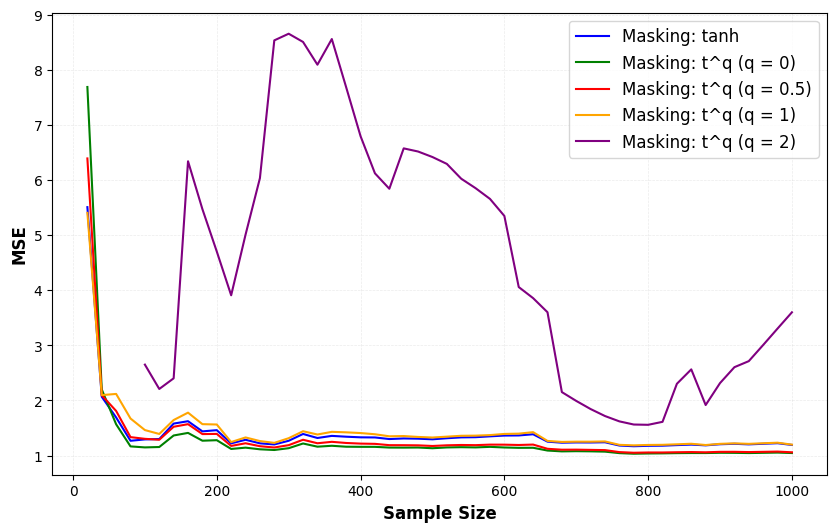

In [164]:
# Define the range of sample sizes (every 10th sample from 10 to 1000)
sample_sizes = np.arange(20, 1001, 20)

# Define the masking parameters
q_values = [-1, 0, 0.5, 1, 2]
colors = ['blue', 'green', 'red', 'orange', 'purple']

# Initialize dictionary to store MSE values for each q
mse_vs_sample_size = {q: np.zeros(len(sample_sizes)) for q in q_values}

# Compute MSE for different sample sizes
for i, n_samples in enumerate(sample_sizes):
    X_train_sampled = X_train[:n_samples]
    Y_train_sampled = Y_train[:n_samples]

    for q in q_values:
        theta_hat_sa, weight_hat_sa = gradient_descent_sa(
            X_train_sampled, Y_train_sampled, theta_init[:n_samples], weight_init[:n_samples],
            gamma_theta, gamma_weight, T_max, q
        )

        mse_temp = 0
        for X_test, Y_test in test_data[fixed_mu]:
            Y_pred = np.dot(X_test, theta_hat_sa[T_max])
            mse_temp += calculate_metrics(Y_test, Y_pred)

        mse_vs_sample_size[q][i] = mse_temp / len(test_data[fixed_mu])

# Plot MSE vs Sample Size
plt.figure(figsize=(10, 6))
for i, q in enumerate(q_values):
    plt.plot(sample_sizes, mse_vs_sample_size[q], label=f"Masking: {'tanh' if q == -1 else f't^q (q = {q})'}", color=colors[i])

plt.xlabel('Sample Size', fontsize=12, fontweight='bold')
plt.ylabel('MSE', fontsize=12, fontweight='bold')
# plt.title('MSE vs Sample Size for Different Masking Functions', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.25)
plt.show()